# Does a neural network outperform a simple, ridge multi-linear regression model for S3 snow depth retrieval?

In this notebook we will compare the ridge multi-linear model for S3 snow depth retrieval we developed in SnowDepthRegression.ipynb against a neural network. 

The dataset preprocessing and the cross-validation method follows exactly that from SnowDepthRegression.ipynb, see that notebook for in-depth descriptions.

In [ ]:
import sys
sys.path.append('/home/cn/NaRRS')
import warnings
import os
import numpy as np
import pandas as pd
import xarray as xr
import verde as vd
import seaborn as sns
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Input
from tensorflow.keras.regularizers import l1_l2
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.callbacks import EarlyStopping

#Set working directory
os.chdir('/home/cn/NaRRS')

#Set hemisphere
hemisphere = 'nh'

## Part 1: Load and preprocess the unified S3-OIB dataset

In [2]:
unified_ds = xr.open_dataset(f'Data/sentinel3_oib_xo_unified.nc')

coord_subset = [f'time_01', f'xc_01', f'yc_01', f'lon_01', f'lat_01']
feature_subset = ['gradient_ratio_corrected_01', 'peakiness_mean_01', 'leading_edge_width_mean_01', 'leading_edge_peakiness_mean_01', 'trailing_edge_decay_mean_01',
                                    'trailing_edge_mean_absolute_deviation_mean_01', 'trailing_edge_width_mean_01', 'sig0_sea_ice_sheet_mean_01','sitype_osisaf_01',
                                    'tb_238_corrected_01', 'tb_365_corrected_01']

#drop index with nan values in any of the variables that we are interestied in exploring
unified_ds = unified_ds.dropna(subset=feature_subset, dim='time_01')

#filter the dataset to only include samples with a minimum number of valid SRAL features in the bin
min_feature_count = 15
unified_ds = unified_ds.where(unified_ds.leading_edge_width_count_01 >= min_feature_count, drop=True)

#constrain the dataset to only include samples with a sea ice concentration 75% or higher
min_sic = 75
unified_ds = unified_ds.where(unified_ds['ice_conc_01'] >= min_sic, drop=True)

print(f'Total appliciable samples in the dataset = {unified_ds.time_01.size}')

#convert the dataset to a dataframe
df = unified_ds.to_dataframe().reset_index()[coord_subset+feature_subset+['mean_snow_depth_01', 'ice_conc_01']]
df = df.dropna().reset_index(drop=True)

#add a new ice_type flag which is 1 if the ice type is MYI and 0 otherwise (FYI and ambiguous ice)
df['ice_type'] = 0
df.loc[df[f'sitype_osisaf_01'] == 3, 'ice_type'] = 1

Total appliciable samples in the dataset = 507


## Part 2: Data splitting

In [3]:
class GroupedBlockedKFold:

    def __init__(self, n_splits=5, spacing=150e3):
        """
        This class is essentially a wrapper around the BlockKFold class from the Verde library which allows for retrieval of balanced folds. 
        
        Parameters:
        n_splits (int): The number of folds to create.
        spacing (float): The grid cell spacing (m) to pass to Verde's BlockKFold, which determines the size of the blocks used for splitting the data.
        """
        self.n_splits = n_splits
        self.spacing = spacing
        self.group_fold_counts = []
        
    def set_generator(self, random_state=0):
        """
        Set the BlockKFold generator with a specified random state. 
        
        Parameters:
        random_state (int): The random state to use for shuffling the blocked data before splitting.
        """
        
        self.bkf = vd.BlockKFold(spacing=self.spacing, n_splits=self.n_splits, balance=True, shuffle=True, random_state=random_state)

    def split(self, coords, groups=None):
        
        """
        Split the data into folds based on the coordinates and group labels.
        For each group, the data is split into folds using the BlockKFold generator, and the train and test indices for each fold are stored in a dictionary. 
        The counts of samples in each fold for each group are also stored in a list of dictionaries.
        
        Parameters:
        coords (array-like): The coordinates of the samples, which will be used for blocking.
        groups (array-like): The group labels for the samples, which will be used for grouping. If None, all samples will be considered as belonging to the same group.
        
        """
        
        if not hasattr(self, 'bkf'):
            print('Generator not set. Setting generator with default random state of 0.')
            self.set_generator()
        
        if groups is None:
            groups = np.zeros(coords.shape[0], dtype=int)
        folds = {}
        for group in np.unique(groups):
            group_indices = np.where(groups == group)[0]
            group_fold_counts = []
            for i, (train, test) in enumerate(self.bkf.split(coords[group_indices])):
                if i not in folds:
                    folds[i] = (group_indices[train], group_indices[test])
                else:
                    folds[i] = (np.concatenate([folds[i][0], group_indices[train]]), np.concatenate([folds[i][1], group_indices[test]]))
                group_fold_counts.append({
                    'train_count': len(group_indices[train]),
                    'test_count': len(group_indices[test]),
                })
            self.group_fold_counts.append({
                'group': group,
                'folds': group_fold_counts
            })

        for fold in folds.values():
            yield fold
    
    def get_fold_counts(self):
        """
        Get the counts of samples in each fold for each group.
        """
        return self.group_fold_counts
    
    def get_df_test_train_indices(self, coords, groups):
        """
        Get the test and train indices for each fold. 
        
        Parameters:
        coords (array-like): The coordinates of the samples, which will be used for blocking.
        groups (array-like): The group labels for the samples, which will be used for grouping. If None, all samples will be considered as belonging to the same group.
        
        Returns:
        list of tuples: each tuple in the list contains the train and test indices for a fold.
        
        """
        train_test_indices = []
        for train, test in self.split(coords, groups):
            train_test_indices.append((train, test))
        return train_test_indices
    
    def get_balanced_random_states(self, coords, groups, max_fold_test_percentage_diff=5):
        """
        Get a list of random states that result in balanced folds.
        Being balanced is defined as a percentage difference between the number of test samples being less than or equal to the specified threshold across the folds. 
        
        Parameters:
        coords (array-like): The coordinates of the samples, which will be used for blocking.
        groups (array-like): The group labels for the samples, which will be used for grouping. If None, all samples will be considered as belonging to the same group.
        max_fold_test_percentage_diff (float): The maximum percentage difference between the percentage of test samples across the folds. Default is 5%.
        
        Returns:
        list: A list of random states that result in balanced folds.
        """
        
        random_states = np.arange(0, 200)
        balanced_random_states = []
        for random_state in random_states:
            self.set_generator(random_state)
            folds = self.get_df_test_train_indices(coords, groups)
            test_percentages = [len(test) / len(groups) for train, test in folds]
            test_percentage_diff = np.max(test_percentages) - np.min(test_percentages)
            if test_percentage_diff <= max_fold_test_percentage_diff/100:
                balanced_random_states.append(random_state)
        if len(balanced_random_states) == 0:
            print('No balanced random states found. Consider increasing the max_fold_test_percentage_diff threshold.')
        return balanced_random_states


Let's create our test-train splits that we'll be using to cross-validate the model

In [4]:
df = df.reset_index(drop=True)
coords = df[['xc_01', 'yc_01']].values
ice_type = df['ice_type']

nsplits = 5 #we'll do 5 folds
spacing = 150e3 #150km block spacing

#initiate the BlockKFold generator and get the balanced random states for the specified parameters. 
groupedblock_generator = GroupedBlockedKFold(n_splits=nsplits, spacing=spacing)
balanced_random_states = groupedblock_generator.get_balanced_random_states(coords, ice_type, max_fold_test_percentage_diff=5)

#set the generator with a balanced random state and get the test train indices for each fold
random_state = balanced_random_states[1]
print(f'Random State: {random_state}')
groupedblock_generator.set_generator(random_state=random_state)
folds = groupedblock_generator.get_df_test_train_indices(coords, ice_type)

Random State: 12


Let's plot the folds to see the spatial distribution of the train/test point and also the distribution of snow depths in each fold

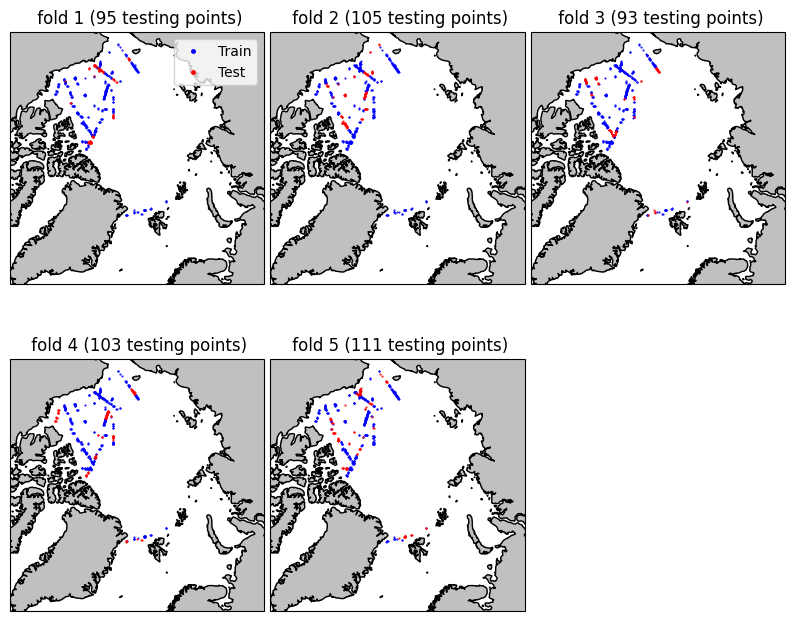

In [5]:
nfolds = len(folds)
nrows = int(np.ceil(nfolds/3))
fig, axs = plt.subplots(nrows,3, figsize=(10, 4.2*nrows), subplot_kw=dict(projection=ccrs.NorthPolarStereo()),sharex=True,sharey=True,)
for i, (ax, fold) in enumerate(zip(axs.ravel(), folds)):
    train, test = fold
    ax.set_title(" fold {} ({} testing points)".format(i+1, test.size))
    ax.add_feature(cfeature.LAND, color = 'silver')
    ax.add_feature(cfeature.COASTLINE)
    ax.set_extent([-180, 180, 68, 90], ccrs.PlateCarree())
    ax.plot(df[f'lon_01'].iloc[train].values, df[f'lat_01'].iloc[train].values,".b",markersize=1,transform=ccrs.PlateCarree(),label="Train")
    ax.plot(df[f'lon_01'].iloc[test].values, df[f'lat_01'].iloc[test].values,".r",markersize=1,transform=ccrs.PlateCarree(),label="Test") 
    if i == 0:
        ax.legend(loc="upper right", markerscale=5)
for ax in axs.ravel()[nfolds:]:
    ax.axis('off')
plt.subplots_adjust(hspace=0.02, wspace=0.025)
plt.show()

## Part 3: Ridge regression model

Here, we will reproduce the optimal ridge multi-linear model found in SnowDepthRegreesion.ipynb. The model has input S3 features of GR, LEW, and TED, and has a ridge parameter (alpha) of 1. We will then perform cross-validation using this configuration.

In [6]:

def make_ridge_pipeline(alpha=1.0, poly_degree=1, solver='auto'):
    """
    Make a sklearn pipeline for ridge regression with polynomial features and standard scaling.
    
    Parameters:
    alpha (float): Regularization strength for ridge regression. Default is 1.0.
    poly_degree (int): Degree of the polynomial features. Default is 1 (no polynomial features).
    solver (str): Solver to use for ridge regression. Default is 'auto'. If the input data is sparse, 'sparse_cg' will be used. If the input data is dense, 'cholesky' will be used.

    Returns:
    sklearn.pipeline.Pipeline: A pipeline object for ridge regression.
    """

    steps = []
    steps.append(('scaler', StandardScaler()))
    steps.append(('poly', PolynomialFeatures(degree=poly_degree)))
    steps.append(('ridge', Ridge(alpha=alpha, solver=solver)))
    return Pipeline(steps)

#=====================================================================================================================================================#

def calculate_prediction_metrics(y_true, y_pred):
    """
    Calculate various performance metrics for model predictions.
    
    Parameters:
    y_true (array-like): The true target values.
    y_pred (array-like): The predicted target values.
    
    Returns:
    tuple: A tuple containing the calculated metrics in the following order: RMSE, R² score, MAE, correlation coefficient (r), and bias.
    """
    
    rmse = root_mean_squared_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    r = np.corrcoef(y_true, y_pred.flatten())[0,1]
    bias = np.mean(y_pred.flatten() - y_true)
    return rmse, r2, mae, r, bias

#=====================================================================================================================================================#

def plot_kfold_predictions_vs_truth(fold_predictions):
    """
    Plots the predicted values against the target OIB values for each fold in a k-fold cross-validation setup.
    
    Parameters:
    fold_predictions (dict): A dictionary where each key is a fold number and each value is another dictionary containing the true target values ('y_test') and the predicted target values ('y_pred') for that fold.
    
    Returns:
    tuple: A tuple containing the figure and axes of the created plot.
    """
    
    nfolds = len(fold_predictions)
    nrows = int(np.ceil(nfolds/3))
    fig, axs = plt.subplots(nrows,3, figsize=(12, 4*nrows),sharex=True,sharey=True,)
    for i, ax in enumerate(axs.ravel()):
        if i >= nfolds:
            ax.axis('off')
            continue
        fold = i + 1
        y_test = fold_predictions[fold]['y_test']
        y_pred = fold_predictions[fold]['y_pred']
        ax = plot_prediction_vs_truth(ax, y_test, y_pred)
        ax.set_title(f'Fold {fold}')
    plt.tight_layout()
    return fig, axs

#=====================================================================================================================================================#

def plot_prediction_vs_truth(ax, y_true, y_pred):
    """
    Plots the predicted values against the target OIB values.
    
    Parameters:
    ax (matplotlib.axes.Axes): The axes on which to plot.
    y_true (array-like): The true target values.
    y_pred (array-like): The predicted target values.
    
    Returns:
    matplotlib.axes.Axes: The axes with the plot.
    """
    
    rmse, r2, mae, r, bias = calculate_prediction_metrics(y_true, y_pred)
    ax.grid(True, alpha=0.5)
    ax.scatter(y_true, y_pred, alpha=0.5)
    ax.plot([0, 0.5], [0, 0.5], color='black', linestyle='--')
    ax.set_xlim(0, 0.5)
    ax.set_ylim(0, 0.5)
    ax.set_xlabel('OIB snow depth (m)')
    ax.set_ylabel('Predicted snow depth (m)')
    ax.text(0.055, 0.70, f'RMSE: {rmse:.2f}\nR$^2$: {r2:.2f}\nMAE: {mae:.2f}\nr: {r:.2f}\nBias: {bias:.2f}', transform=ax.transAxes)
    return ax


Define the optimal ridge multi-linear regression model and conduct cross-validation

In [7]:
alpha = 1
ridge_input_features = ['gradient_ratio_corrected_01', 'leading_edge_width_mean_01', 'trailing_edge_decay_mean_01']

X = df[ridge_input_features]
y = df[f'mean_snow_depth_01']

fold_predictions = {}
fold_results_df = pd.DataFrame({'Fold': range(1, nsplits + 1)})

for i, (train_idx, test_idx) in enumerate(folds):
    fold = i + 1
    X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
    X_test, y_test = X.iloc[test_idx], y.iloc[test_idx]

    pipeline = make_ridge_pipeline(alpha=alpha)

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    fold_predictions[fold] = {'y_test': y_test, 'y_pred': y_pred}
    
    fold_results_df.loc[fold_results_df['Fold'] == fold, ['RMSE', 'R2', 'MAE', 'r', 'Bias']] = calculate_prediction_metrics(y_test, y_pred)
    fold_results_df.loc[fold_results_df['Fold'] == fold, 'N_train'] = len(y_train)
    fold_results_df.loc[fold_results_df['Fold'] == fold, 'N_test'] = len(y_test)
    fold_results_df.loc[fold_results_df['Fold'] == fold, 'N_group_0_train'] = len(np.where(ice_type.iloc[train_idx] == 0)[0])
    fold_results_df.loc[fold_results_df['Fold'] == fold, 'N_group_0_test'] = len(np.where(ice_type.iloc[test_idx] == 0)[0])
    fold_results_df.loc[fold_results_df['Fold'] == fold, 'N_group_1_train'] = len(np.where(ice_type.iloc[train_idx] == 1)[0])
    fold_results_df.loc[fold_results_df['Fold'] == fold, 'N_group_1_test'] = len(np.where(ice_type.iloc[test_idx] == 1)[0])

In [8]:
print(fold_results_df)

   Fold      RMSE        R2       MAE         r      Bias  N_train  N_test  \
0     1  0.049853  0.844179  0.041296  0.938150 -0.015764    412.0    95.0   
1     2  0.039106  0.730639  0.032594  0.903140  0.021947    402.0   105.0   
2     3  0.046366  0.600429  0.039130  0.820452  0.011251    414.0    93.0   
3     4  0.049283  0.758732  0.037444  0.873374 -0.002426    404.0   103.0   
4     5  0.044906  0.652650  0.035198  0.848859 -0.013251    396.0   111.0   

   N_group_0_train  N_group_0_test  N_group_1_train  N_group_1_test  
0            268.0            59.0            144.0            36.0  
1            256.0            71.0            146.0            34.0  
2            265.0            62.0            149.0            31.0  
3            260.0            67.0            144.0            36.0  
4            259.0            68.0            137.0            43.0  


In [ ]:
print('CV Results:')
print(f'Mean R2: {fold_results_df["R2"].mean()} ± {fold_results_df["R2"].std()}')
print(f'Mean RMSE: {fold_results_df["RMSE"].mean()} ± {fold_results_df["RMSE"].std()}')
print(f'Mean MAE: {fold_results_df["MAE"].mean()}  ± {fold_results_df["MAE"].std()}')
print(f'Mean r: {fold_results_df["r"].mean()} ± {fold_results_df["r"].std()}')
print(f'Mean Bias: {fold_results_df["Bias"].mean()} ± {fold_results_df["Bias"].std()}')

CV Results:
Mean R2: 0.7173256342063732 ± 0.09464574369313203
Mean RMSE: 0.04590256902553717 ± 0.004313934018427583
Mean MAE: 0.03713270086210975  ± 0.0033822953699844485
Mean r: 0.8767949860889633 ± 0.04589409052641879
Mean Bias: 0.0003511260902234442 ± 0.016105845289195526


Let's visualise our predictions against the target OIB snow depths for each fold

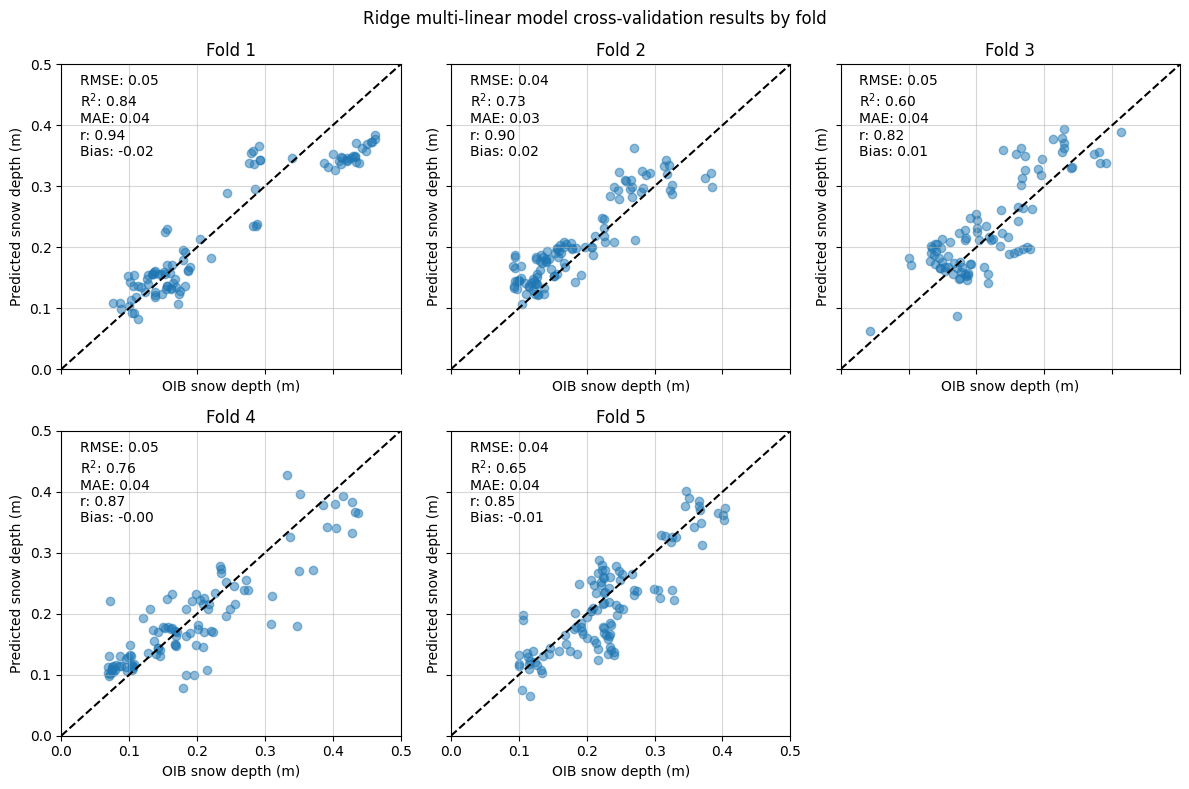

In [10]:
# plot the predictions vs true values for each fold
fig, axs = plot_kfold_predictions_vs_truth(fold_predictions)
fig.suptitle("Ridge multi-linear model cross-validation results by fold")
plt.tight_layout()
plt.show()

## Part 4: Neural Network

We will compare the results from our ridge multi-linear regression model with those from a Multilayer Perceptron (MLP) neural network. This neural network will have access to the original 7 tested input S3 features, rather than only the three used by our optimal ridge model.

Given the relatively small training dataset size, we will construct a relative shallow MLP consisting of two hidden layers: a 4-neuron layer followed by a 2-neuron layer. To further mitigate overfitting, we will apply L1 (Lasso) and L2 (Ridge) regularization at each hidden layer. To find the optimal L1 and L2 regularization values, we'll use a grid search. We will also apply early stopping and examine the training and validation loss curves to ensure the model was not overfitted.

Note that results may differ slightly on each run of this notebook due to the stochastic nature of the MLP.

In [12]:
def plot_validation_loss_curve(ax, train_loss, val_loss, logy=False):

    """
    Plots the training and validation loss curves for a single fold.
    
    Parameters:
    ax (matplotlib.axes.Axes): The axes on which to plot.
    train_loss (array-like): The training loss values for each epoch.
    val_loss (array-like): The validation loss values for each epoch.
    logy (bool): Whether to use a logarithmic scale for the y-axis. Default is False
    
    Returns:
    matplotlib.axes.Axes: The axes with the plot.
    """
    epochs = np.arange(1, len(train_loss) + 1)
    if logy:
        ax.set_yscale('log')
    ax.plot(epochs, train_loss, label='Train', color='blue')
    ax.plot(epochs, val_loss, label='Validation', color='red')
    ax.set_title('Training Loss')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()
    return ax

#=====================================================================================================================================================#

def plot_kfold_validation_loss_curve(train_losses, val_losses, sharex=True, sharey=True, logy=False):
    """
    Plots the training and validation loss curves for each fold in a k-fold cross-validation setup.

    Parameters:
    train_losses (list of array-like): A list where each element is an array of training loss values for each epoch for a fold.
    val_losses (list of array-like): A list where each element is an array of validation loss values for each epoch for a fold.
    sharex (bool): Whether to share the x-axis across the subplots. Default is True.
    sharey (bool): Whether to share the y-axis across the subplots. Default is True.
    logy (bool): Whether to use a logarithmic scale for the y-axis. Default is False.

    Returns:
    tuple: A tuple containing the figure and axes of the created plot.
    """
    
    nfolds = len(train_losses)
    nrows = int(np.ceil(nfolds/3))
    fig, axs = plt.subplots(nrows,3, figsize=(15, 5*nrows),sharey=sharey, sharex=sharex)
    for i, ax in enumerate(axs.ravel()):
        if i >= nfolds:
            ax.axis('off')
            continue
        fold = i + 1
        ax = plot_validation_loss_curve(ax, train_losses[i], val_losses[i], logy=logy)
        ax.set_title(f'Fold {fold}')
    plt.tight_layout()
    return fig, axs

#=====================================================================================================================================================#


Find the optimal regularization parameters using a grid search and cross-validation

In [ ]:
nn_feature_cols = [ 'gradient_ratio_corrected_01', 'leading_edge_width_mean_01', 'peakiness_mean_01', 'leading_edge_peakiness_mean_01',
                 'trailing_edge_width_mean_01',  'sig0_sea_ice_sheet_mean_01', 'trailing_edge_decay_mean_01',]

X = df[nn_feature_cols]

#define the regularization parameters search space
l1_values = [0.0, 0.001, 0.01, 0.1, 1]
l2_values = [0.0, 0.001, 0.01, 0.1, 1]

#set a keras random seed to help reproducibility, though there is still some randomness in the MLP training process
tf.keras.utils.set_random_seed(1)

results = []

for l1_lambda in l1_values:
    for l2_lambda in l2_values:
        print(f"Testing l1_lambda={l1_lambda}, l2_lambda={l2_lambda}")
        
        fold_val_losses = []
        
        for fold, (train, test) in enumerate(groupedblock_generator.split(coords, ice_type)):
            fold = fold + 1
            X_train, y_train = X.iloc[train], y.iloc[train]
            X_test, y_test = X.iloc[test], y.iloc[test]

            X_scaler = StandardScaler().fit(X_train.values)
            X_train = X_scaler.transform(X_train.values)
            X_test = X_scaler.transform(X_test.values)

            # define the neaural network architecture
            model = Sequential([
                Input(shape=(X.shape[1],)),
                Dense(4, activation='relu', kernel_regularizer=l1_l2(l1=l1_lambda, l2=l2_lambda)),
                BatchNormalization(),
                Dense(2, activation='relu', kernel_regularizer=l1_l2(l1=l1_lambda, l2=l2_lambda)),
                BatchNormalization(),
                Dense(1)
            ])
            
            optimizer = Adam(learning_rate=0.001)
            #compile the model
            model.compile(optimizer=optimizer, loss='mean_squared_error')
            
            #add early stopping
            early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
            
            #train the model
            history = model.fit(
                X_train, y_train,
                validation_data=(X_test, y_test),
                epochs=250,
                batch_size=32,
                callbacks=[early_stopping],
                verbose=0
            )
            
            #store the minimum validation loss for this fold
            fold_val_losses.append(min(history.history['val_loss']))
        
        #calculate the mean validation loss across all folds
        mean_val_loss = np.mean(fold_val_losses)
        results.append((l1_lambda, l2_lambda, mean_val_loss))
        print(f"Mean Validation Loss: {mean_val_loss}")


Testing l1_lambda=0.0, l2_lambda=0.0
Mean Validation Loss: 0.043021619459614156
Testing l1_lambda=0.0, l2_lambda=0.001
Mean Validation Loss: 0.09806195441633463
Testing l1_lambda=0.0, l2_lambda=0.01
Mean Validation Loss: 0.0637211843393743
Testing l1_lambda=0.0, l2_lambda=0.1
Mean Validation Loss: 0.14844950705301016
Testing l1_lambda=0.0, l2_lambda=1
Mean Validation Loss: 0.010256905062124132
Testing l1_lambda=0.001, l2_lambda=0.0
Mean Validation Loss: 0.01937206294387579
Testing l1_lambda=0.001, l2_lambda=0.001
Mean Validation Loss: 0.05100280549377203
Testing l1_lambda=0.001, l2_lambda=0.01
Mean Validation Loss: 0.06862124896142632
Testing l1_lambda=0.001, l2_lambda=0.1
Mean Validation Loss: 0.006627787044271827
Testing l1_lambda=0.001, l2_lambda=1
Mean Validation Loss: 0.002404174511320889
Testing l1_lambda=0.01, l2_lambda=0.0
Mean Validation Loss: 0.06155880452133715
Testing l1_lambda=0.01, l2_lambda=0.001
Mean Validation Loss: 0.12762363406363875
Testing l1_lambda=0.01, l2_lambda

In [32]:
#find the best combination
best_combination = min(results, key=lambda x: x[2])
print(f"Best l1_lambda: {best_combination[0]}, Best l2_lambda: {best_combination[1]}, Validation Loss: {best_combination[2]}")

Best l1_lambda: 0.001, Best l2_lambda: 1, Validation Loss: 0.002404174511320889


Having found the best combination of regularization parameters, we'll fit the model to this combination and reperform cross-validation; saving the results to compute with those from our ridge model

In [ ]:
#from above Best l1_lambda: 0.001, Best l2_lambda: 1
# best_combination = (0.001, 1)

fold_results_df_nn = pd.DataFrame({'Fold': range(1, nsplits + 1)})
train_losses = []
val_losses = []
fold_predictions_nn = {}

for fold, (train, test) in enumerate(groupedblock_generator.split(coords, ice_type)):
    fold = fold + 1
    X_train, y_train = X.iloc[train], y.iloc[train]
    X_test, y_test = X.iloc[test], y.iloc[test]

    X_scaler = StandardScaler().fit(X_train.values)
    X_train = X_scaler.transform(X_train.values)
    X_test = X_scaler.transform(X_test.values)

    #define L1 and L2 from our found best combination
    l1_lambda = best_combination[0]
    l2_lambda = best_combination[1]

    model = Sequential()
    model.add(Input(shape=(X.shape[1],)))
    model.add(Dense(4, activation='relu', kernel_regularizer=l1_l2(l1=l1_lambda, l2=l2_lambda)))
    model.add(BatchNormalization())
    model.add(Dense(2, activation='relu', kernel_regularizer=l1_l2(l1=l1_lambda, l2=l2_lambda)))
    model.add(BatchNormalization())
    model.add(Dense(1))

    lr = 0.001
    optimizer = Adam(learning_rate=lr)
    model.compile(optimizer=optimizer, loss='mean_squared_error')

    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True
    )

    epochs = 250
    batch_size = 32
    history = model.fit(
        X_train, y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_data=(X_test, y_test),
        callbacks=[early_stopping], 
        verbose=0
    )

    train_losses.append(history.history['loss'])
    val_losses.append(history.history['val_loss'])

    y_pred = model(X_test)
    y_pred = y_pred.numpy().flatten()
    
    del model

    fold_predictions_nn[fold] = {'y_test': y_test, 'y_pred': y_pred}
    
    fold_results_df_nn.loc[fold_results_df_nn['Fold'] == fold, ['RMSE', 'R2', 'MAE', 'r', 'Bias']] = calculate_prediction_metrics(y_test, y_pred)
    fold_results_df_nn.loc[fold_results_df_nn['Fold'] == fold, 'N_train'] = len(y_train)
    fold_results_df_nn.loc[fold_results_df_nn['Fold'] == fold, 'N_test'] = len(y_test)
    fold_results_df_nn.loc[fold_results_df_nn['Fold'] == fold, 'N_group_0_train'] = len(np.where(ice_type.iloc[train] == 0)[0])
    fold_results_df_nn.loc[fold_results_df_nn['Fold'] == fold, 'N_group_0_test'] = len(np.where(ice_type.iloc[test] == 0)[0])
    fold_results_df_nn.loc[fold_results_df_nn['Fold'] == fold, 'N_group_1_train'] = len(np.where(ice_type.iloc[train] == 1)[0])
    fold_results_df_nn.loc[fold_results_df_nn['Fold'] == fold, 'N_group_1_test'] = len(np.where(ice_type.iloc[test] == 1)[0])


Let's have a visual look at the cross-validation and study the loss curves for each fold to ensure the model was not being over fitted

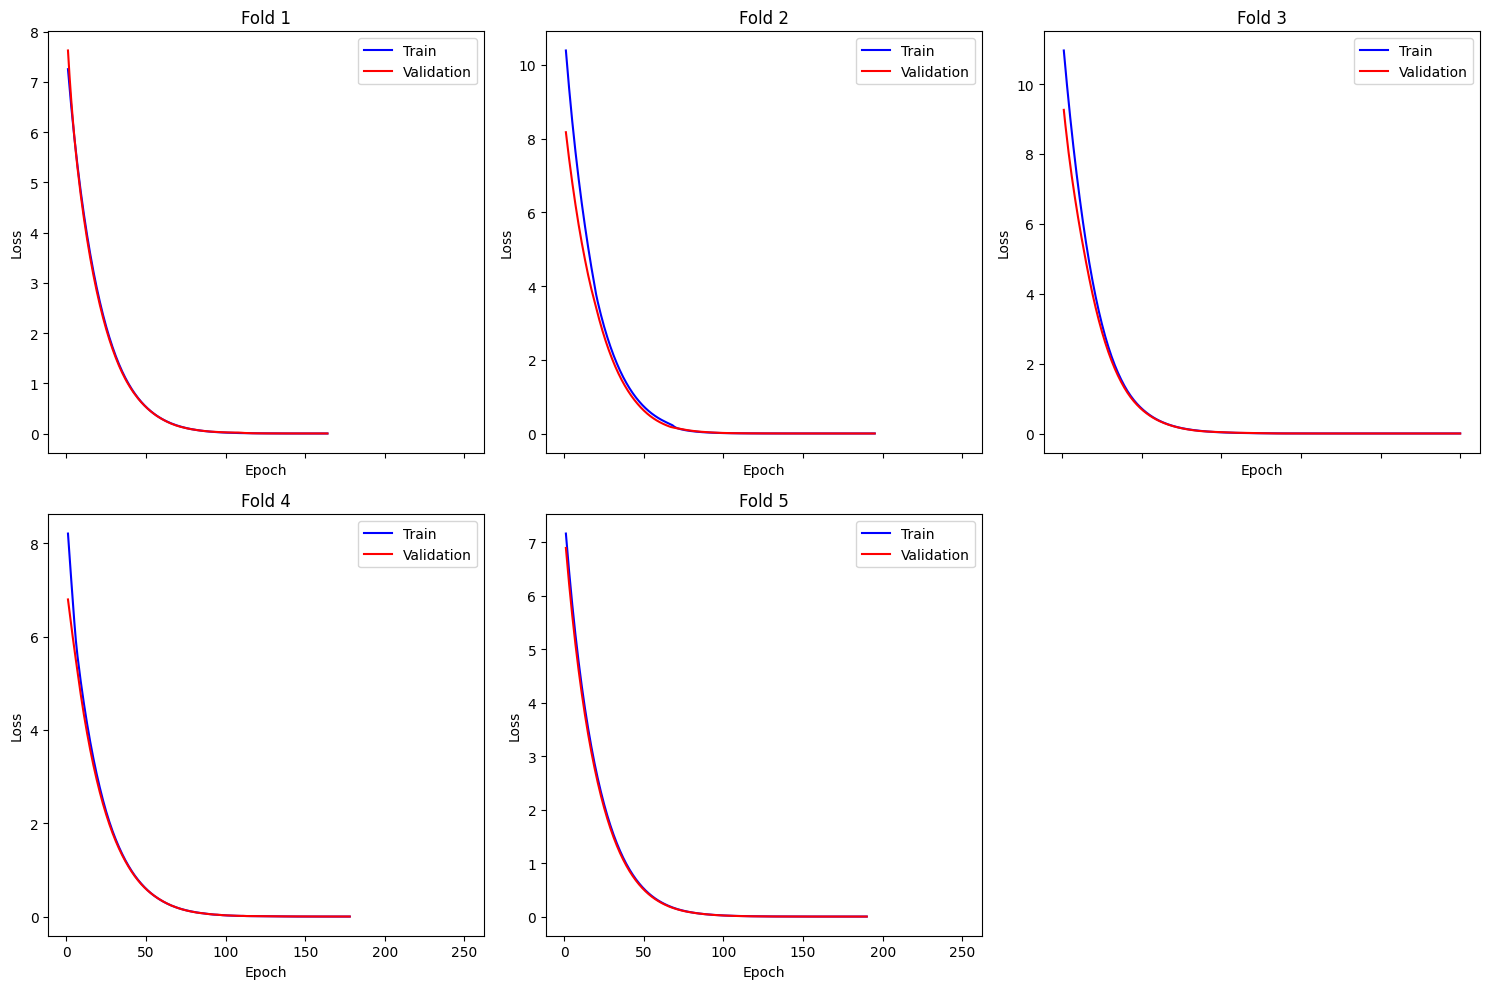

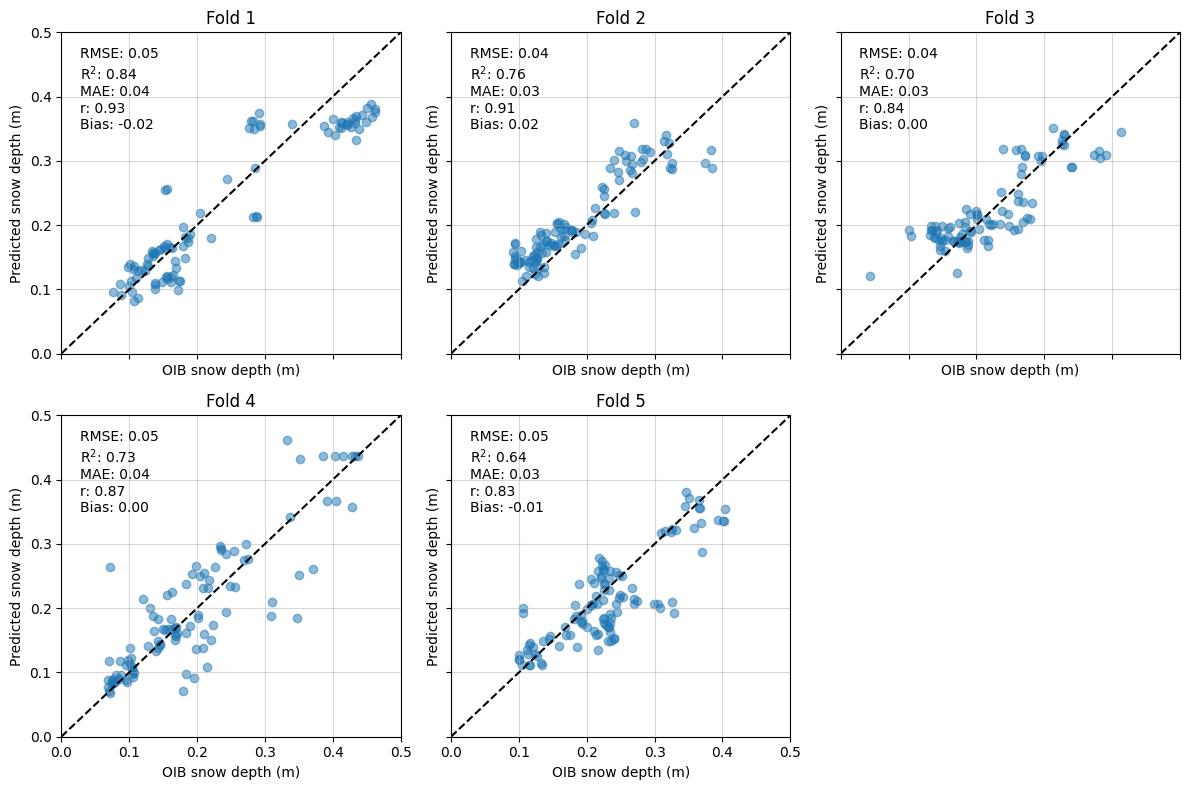

In [51]:
#plot the mean training and validation losses of each fold
fig, ax = plot_kfold_validation_loss_curve(train_losses, val_losses, sharey=False, logy=False)
plt.show()

#plot the predictions vs true values for each fold
fig, axs = plot_kfold_predictions_vs_truth(fold_predictions_nn)
plt.show()

## Part 5: Model comparison

Here, we will compare the cross-validation results of the two models

In [52]:
fold_results_df_nn['Model'] = 'Neural Network'
fold_results_df['Model'] = 'Ridge Multilinear'
combined_results = pd.concat([fold_results_df, fold_results_df_nn])
combined_results_melted = pd.melt(combined_results, id_vars=['Model'], value_vars=['R2', 'r', 'RMSE', 'MAE', 'Bias'], var_name='Metric', value_name='Value')

/tmp/ipykernel_3636154/2352782993.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[0].set_xticklabels(['R$^2$', 'r'])
/tmp/ipykernel_3636154/2352782993.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[1].set_xticklabels(['MAE', 'RMSE', 'Bias'])


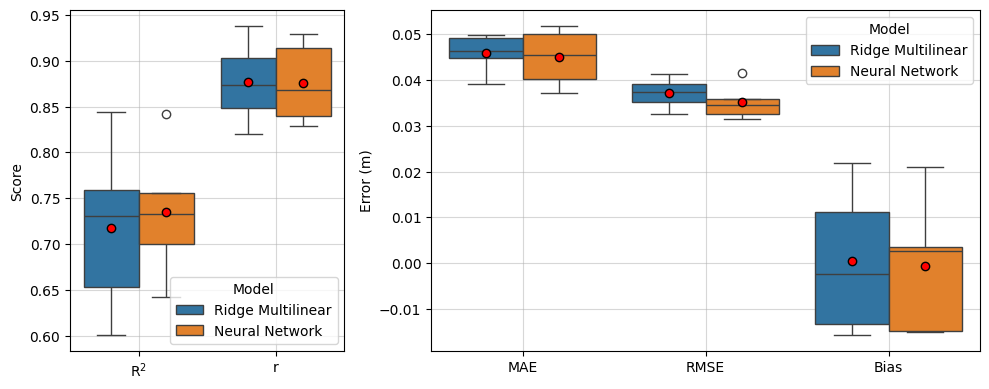

In [53]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4), gridspec_kw={'width_ratios': [1, 2]})
metrics_1 = ['R2', 'r']
sns.boxplot(data=combined_results_melted[combined_results_melted['Metric'].isin(metrics_1)], 
            x='Metric', y='Value', hue='Model', ax=axs[0], showmeans=True, 
            meanprops={'marker': 'o', 'markerfacecolor': 'red', 'markeredgecolor': 'black', 'markersize': '6'})
axs[0].set_xlabel('')
axs[0].set_ylabel('Score')
axs[0].set_xticklabels(['R$^2$', 'r'])
axs[0].grid(True, alpha=0.5)
axs[0].legend(title='Model', loc='lower right')
metrics_2 = ['MAE', 'RMSE', 'Bias']
sns.boxplot(data=combined_results_melted[combined_results_melted['Metric'].isin(metrics_2)], 
            x='Metric', y='Value', hue='Model', ax=axs[1], showmeans=True, 
            meanprops={'marker': 'o', 'markerfacecolor': 'red', 'markeredgecolor': 'black', 'markersize': '6'})
axs[1].set_xlabel('')
axs[1].set_ylabel('Error (m)')
axs[1].set_xticklabels(['MAE', 'RMSE', 'Bias'])
axs[1].grid(True, alpha=0.5)
axs[1].legend(title='Model', loc='upper right')
plt.tight_layout()
plt.show()

In [54]:
print('Ridge Regression CV Results:')
print(f'Mean R2: {fold_results_df["R2"].mean()} ± {fold_results_df["R2"].std()}')
print(f'Mean RMSE: {fold_results_df["RMSE"].mean()} ± {fold_results_df["RMSE"].std()}')
print(f'Mean MAE: {fold_results_df["MAE"].mean()}  ± {fold_results_df["MAE"].std()}')
print(f'Mean r: {fold_results_df["r"].mean()} ± {fold_results_df["r"].std()}')
print(f'Mean Bias: {fold_results_df["Bias"].mean()} ± {fold_results_df["Bias"].std()}')

print('Neural Network CV Results:')
print(f'Mean R2: {fold_results_df_nn["R2"].mean()} ± {fold_results_df_nn["R2"].std()}')
print(f'Mean RMSE: {fold_results_df_nn["RMSE"].mean()} ± {fold_results_df_nn["RMSE"].std()}')
print(f'Mean MAE: {fold_results_df_nn["MAE"].mean()}  ± {fold_results_df_nn["MAE"].std()}')
print(f'Mean r: {fold_results_df_nn["r"].mean()} ± {fold_results_df_nn["r"].std()}')
print(f'Mean Bias: {fold_results_df_nn["Bias"].mean()} ± {fold_results_df_nn["Bias"].std()}')

Ridge Regression CV Results:
Mean R2: 0.7173256342063732 ± 0.09464574369313203
Mean RMSE: 0.04590256902553717 ± 0.004313934018427583
Mean MAE: 0.03713270086210975  ± 0.0033822953699844485
Mean r: 0.8767949860889633 ± 0.04589409052641879
Mean Bias: 0.0003511260902234442 ± 0.016105845289195526
Neural Network CV Results:
Mean R2: 0.7344826835493208 ± 0.07369161229261481
Mean RMSE: 0.0450116637074279 ± 0.0062612275184475465
Mean MAE: 0.03523824415305829  ± 0.0039493599336966
Mean r: 0.8759362180121562 ± 0.04432989014793685
Mean Bias: -0.0005654981833136893 ± 0.015101586743100458


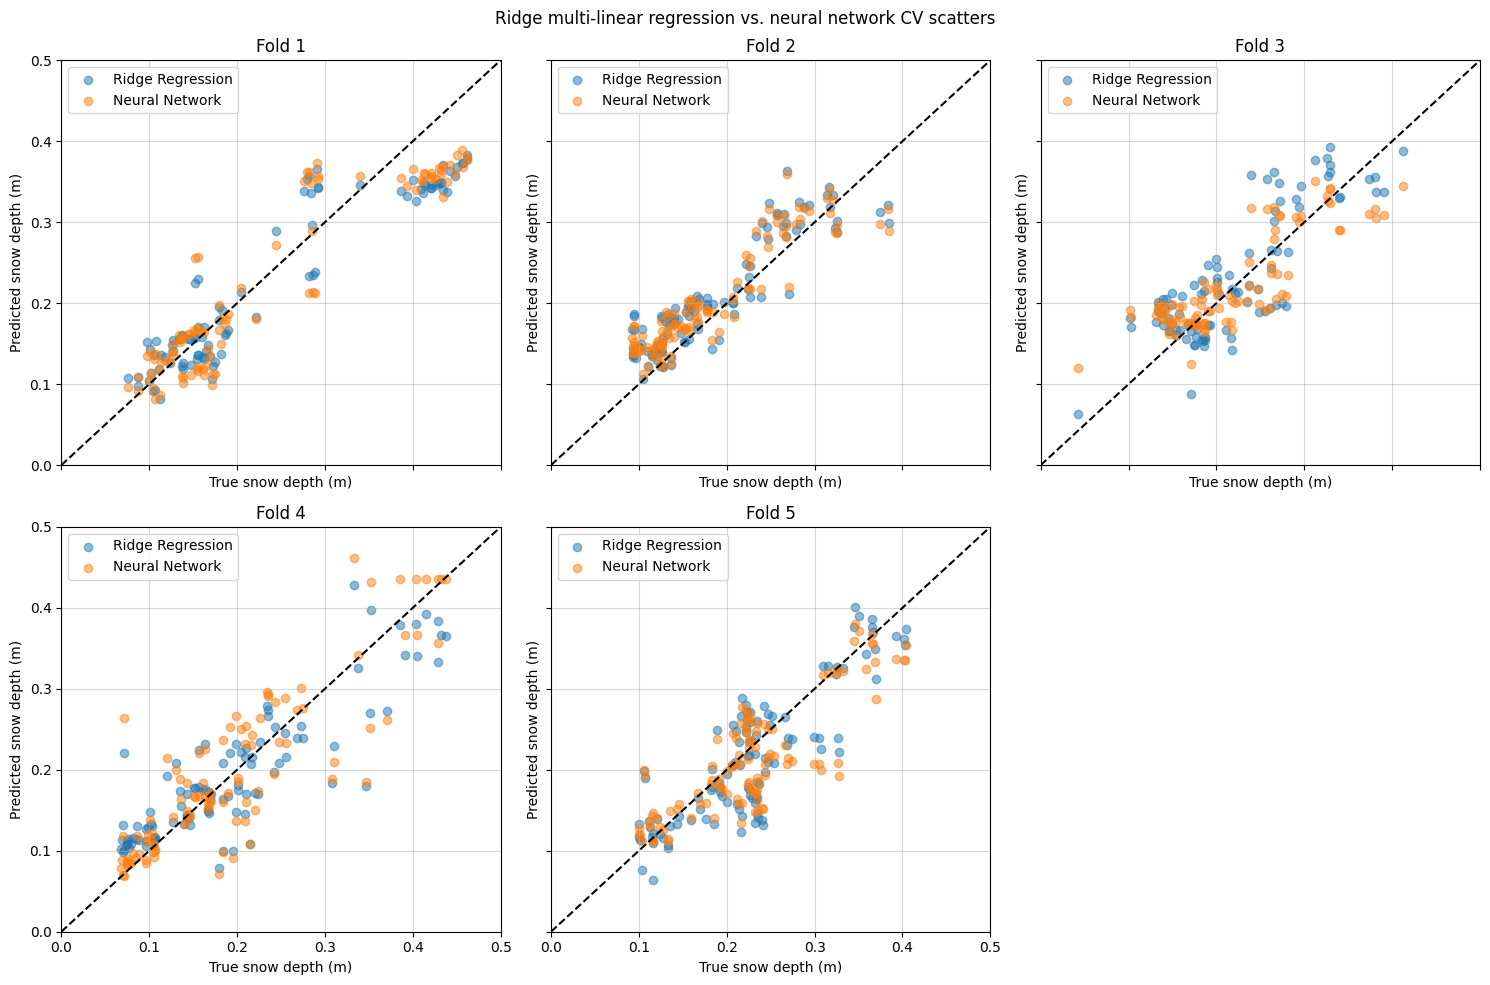

In [55]:
nfolds = len(train_losses)
nrows = int(np.ceil(nfolds/3))
fig, axs = plt.subplots(nrows,3, figsize=(15, 5*nrows),sharey=True, sharex=True,)
for i, ax in enumerate(axs.ravel()):
    if i >= nfolds:
        ax.axis('off')
        continue
    fold = i + 1
    y_test_nn = fold_predictions_nn[fold]['y_test']
    y_pred_nn = fold_predictions_nn[fold]['y_pred']
    y_test = fold_predictions[fold]['y_test']
    y_pred = fold_predictions[fold]['y_pred']
    ax.grid(True, alpha=0.5)
    ax.scatter(y_test, y_pred, alpha=0.5, label='Ridge Regression')
    ax.scatter(y_test_nn, y_pred_nn, alpha=0.5, label='Neural Network')
    ax.plot([0, 0.5], [0, 0.5], color='black', linestyle='--')
    ax.set_xlim(0, 0.5)
    ax.set_ylim(0, 0.5)
    ax.set_xlabel('True snow depth (m)')
    ax.set_ylabel('Predicted snow depth (m)')
    ax.set_title(f'Fold {fold}')
    ax.legend()
fig.suptitle("Ridge multi-linear regression vs. neural network CV scatters")
plt.tight_layout()
plt.show()

Overall, the two models perform very similar. The neural network is perhaps squeezing a little bit of extra information from the training data, reflected in e.g., the slightly lower RMSE and tighter R² spread, but it is at the cost of accessing 4 extra variables which may lead to more data loss in its operational application due to our quality-control filtering processes. Furthermore, we can obtain an equation from the multi-linear model that we can easily interperet to study the physical relationships at play, whereas interpreting the neural network is much more complicated. Giving the minimal performance gap for the mentioned costs, continuing with the more simple and interpretable ridge multi-linear model is a reasonable choice.